# 02 — Visualising SUPPA results across boundary modes

This notebook tells the story of how the boundary parameter affects
what SUPPA detects, in two steps:

1. **How many events are detected** by generateEvents (IOE counts) —
   all 7 event types, all 6 boundary modes
2. **How many of those are significant** (p < 0.05, |dPSI| ≥ 0.1) —
   focusing on A3, A5, RI for Strict, Variable 1nt and Variable 5nt

The goal is to show that variable mode captures more biologically
relevant events, especially for RI (retained introns).

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [51]:
# All events detected by generateEvents across all boundary modes
data_ioe_all = {
    "Event":        ["SE",   "A3",   "A5",   "MX",  "RI",   "AF",   "AL"],
    "Strict":       [22523, 11164,  9630,  2607,  5316, 33108,  7632],
    "Variable 1nt": [22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 3nt": [22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 5nt": [22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 10nt":[22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 20nt":[22523, 22932, 19456,  2607, 17337, 33108,  7632],
}

df_ioe_all = pd.DataFrame(data_ioe_all)

def highlight_focus(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    focus_rows = df["Event"].isin(["A3", "A5", "RI"])
    focus_cols = ["Strict", "Variable 1nt", "Variable 5nt"]
    for col in focus_cols:
        if col in df.columns:
            styles.loc[focus_rows, col] = "color: #2196F3; font-weight: bold"
    return styles

display(df_ioe_all.style\
    .apply(highlight_focus, axis=None)\
    .set_caption("Events detected by generateEvents across all boundary modes"))

,Event,Strict,Variable 1nt,Variable 3nt,Variable 5nt,Variable 10nt,Variable 20nt
0,SE,22523,22523,22523,22523,22523,22523
1,A3,11164,22932,22932,22932,22932,22932
2,A5,9630,19456,19456,19456,19456,19456
3,MX,2607,2607,2607,2607,2607,2607
4,RI,5316,17337,17337,17337,17337,17337
5,AF,33108,33108,33108,33108,33108,33108
6,AL,7632,7632,7632,7632,7632,7632


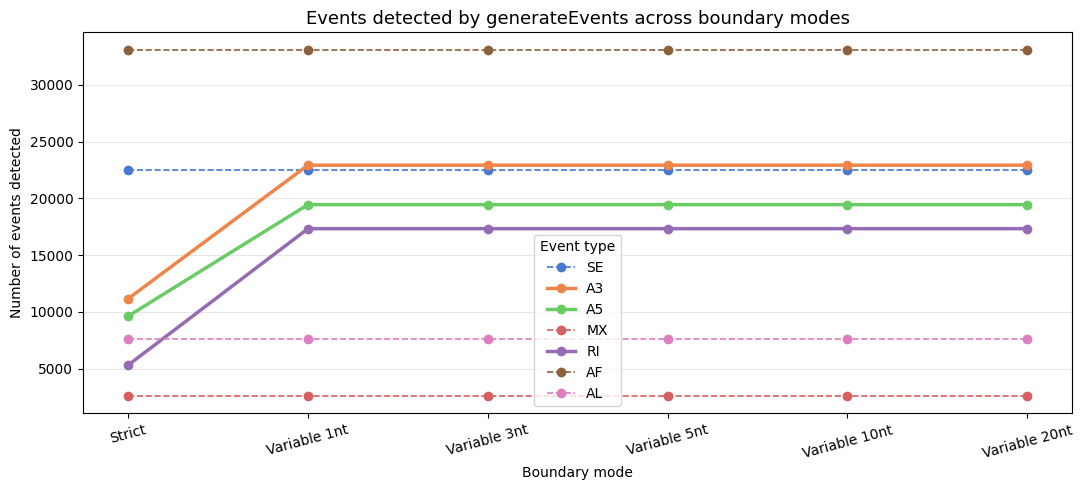

In [52]:
# Line plot — IOE counts across all boundary modes for all 7 events
boundaries = ["Strict", "Variable 1nt", "Variable 3nt", "Variable 5nt", "Variable 10nt", "Variable 20nt"]

fig, ax = plt.subplots(figsize=(11, 5))

muted = sns.color_palette("muted", 7)
events_all = ["SE", "A3", "A5", "MX", "RI", "AF", "AL"]

for i, event in enumerate(events_all):
    row = df_ioe_all[df_ioe_all["Event"] == event].iloc[0]
    values = [row[b] for b in boundaries]
    linestyle = "-" if event in ["A3", "A5", "RI"] else "--"
    linewidth = 2.5 if event in ["A3", "A5", "RI"] else 1.2
    ax.plot(boundaries, values, marker="o", label=event,
            color=muted[i], linewidth=linewidth, linestyle=linestyle)

ax.set_title("Events detected by generateEvents across boundary modes", fontsize=13)
ax.set_xlabel("Boundary mode")
ax.set_ylabel("Number of events detected")
ax.legend(title="Event type")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../../figures/plots/lineplot_ioe_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
# Significant events CT8 vs CT20 (p < 0.05, |dPSI| >= 0.1)
data_ct8 = {
    "Event": ["A3", "A5", "RI"],
    "Strict":       [36, 35, 11],
    "Variable 1nt": [73, 63, 62],
    "Variable 5nt": [75, 60, 61],
}

# Significant events CT20 vs PerKO (p < 0.05, |dPSI| >= 0.1)
data_perko = {
    "Event": ["A3", "A5", "RI"],
    "Strict":       [45, 47, 13],
    "Variable 1nt": [73, 76, 64],
    "Variable 5nt": [74, 72, 65],
}

df_ct8 = pd.DataFrame(data_ct8)
df_perko = pd.DataFrame(data_perko)

print("CT8 vs CT20:")
display(df_ct8)
print("CT20 vs PerKO:")
display(df_perko)

CT8 vs CT20:


,Event,Strict,Variable 1nt,Variable 5nt
0,A3,36,73,75
1,A5,35,63,60
2,RI,11,62,61


CT20 vs PerKO:


,Event,Strict,Variable 1nt,Variable 5nt
0,A3,45,73,74
1,A5,47,76,72
2,RI,13,64,65


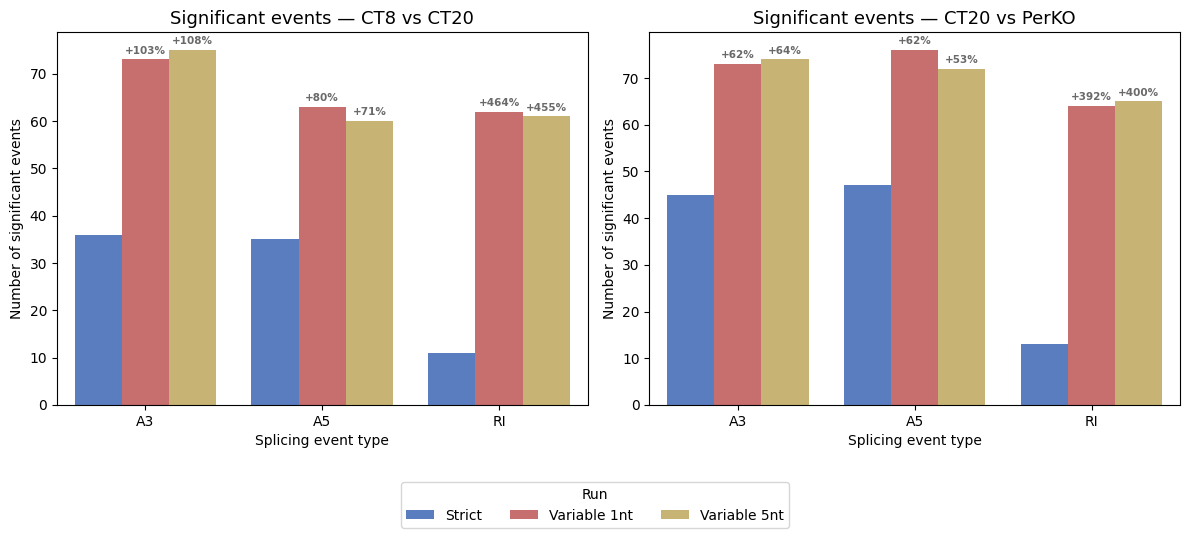

Plot saved to figures/plots/!


In [60]:
def add_pct_labels(ax, df):
    bars = ax.patches
    events = df["Event"].tolist()
    n_events = len(events)
    
    for i, event in enumerate(events):
        strict_val = df[df["Event"] == event]["Strict"].values[0]
        
        # Variable 1nt bars are at index n_events + i
        bar_1nt = bars[n_events + i]
        pct_1nt = ((df[df["Event"] == event]["Variable 1nt"].values[0] - strict_val) / strict_val) * 100
        ax.text(bar_1nt.get_x() + bar_1nt.get_width() / 2,
                bar_1nt.get_height() + 0.8,
                f"+{pct_1nt:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
                color="dimgray", fontweight="bold")
        
        # Variable 5nt bars are at index 2*n_events + i
        bar_5nt = bars[2 * n_events + i]
        pct_5nt = ((df[df["Event"] == event]["Variable 5nt"].values[0] - strict_val) / strict_val) * 100
        ax.text(bar_5nt.get_x() + bar_5nt.get_width() / 2,
                bar_5nt.get_height() + 0.8,
                f"+{pct_5nt:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
                color="dimgray", fontweight="bold")

# Bar plots for CT8 vs CT20 and CT20 vs PerKO

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reshape data for seaborn
df_ct8_melted = df_ct8.melt(id_vars="Event", var_name="Run", value_name="Count")
df_perko_melted = df_perko.melt(id_vars="Event", var_name="Run", value_name="Count")

# Colors
# palette = {"Strict": "steelblue", "Variable 1nt": "salmon", "Variable 5nt": "mediumseagreen"}
muted = sns.color_palette("muted")
palette = {"Strict": muted[0], "Variable 1nt": muted[3], "Variable 5nt": muted[8]}

# Plot 1 — CT8 vs CT20
sns.barplot(data=df_ct8_melted, x="Event", y="Count", hue="Run",
            palette=palette, ax=axes[0])
axes[0].set_title("Significant events — CT8 vs CT20", fontsize=13)
axes[0].set_xlabel("Splicing event type")
axes[0].set_ylabel("Number of significant events")

# Plot 2 — CT20 vs PerKO
sns.barplot(data=df_perko_melted, x="Event", y="Count", hue="Run",
            palette=palette, ax=axes[1])
axes[1].set_title("Significant events — CT20 vs PerKO", fontsize=13)
axes[1].set_xlabel("Splicing event type")
axes[1].set_ylabel("Number of significant events")

# Annotate percentage increases above Variable bars
add_pct_labels(axes[0], df_ct8)
add_pct_labels(axes[1], df_perko)

# Remove individual legends and add a combined legend below
axes[0].get_legend().remove()
axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Run", loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig("../../figures/plots/barplot_strict_vs_variable.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to figures/plots/!")